<a href="https://colab.research.google.com/github/jayavardhanchundru-jpg/Machine-Leraning/blob/main/Exp1%20PL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = sns.load_dataset('titanic')

print(df.head())
print(df.shape)

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
(891, 15)


In [3]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nNumerical Statistics:")
print(df.describe())

print("\nCategorical Statistics:")
print(df.describe(include='object'))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

Missing Values:
survived         0
pclass           0
sex              0


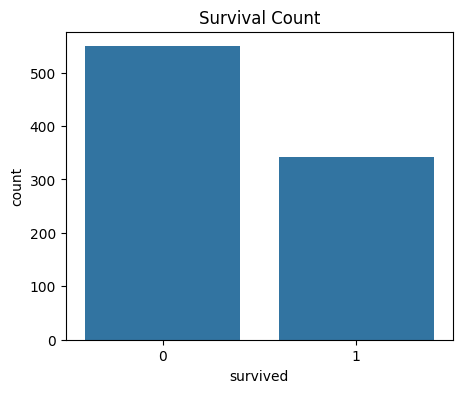

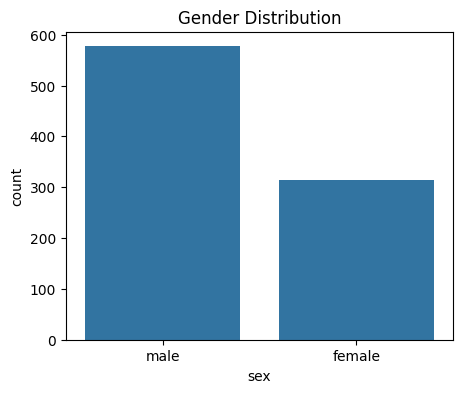

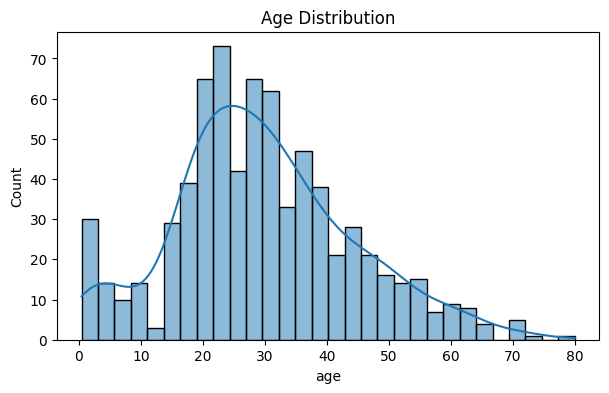

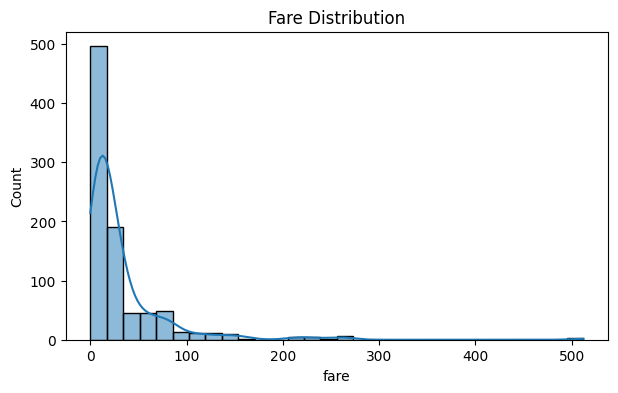

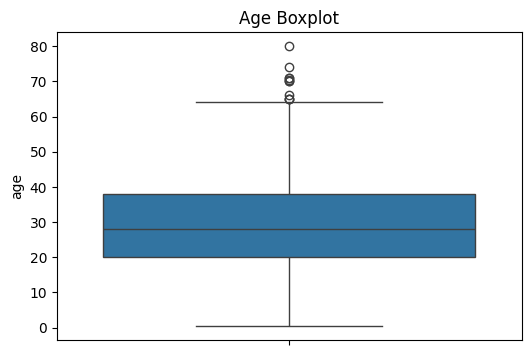

In [4]:
plt.figure(figsize=(5,4))
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(df['fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(y='age', data=df)
plt.title("Age Boxplot")
plt.show()

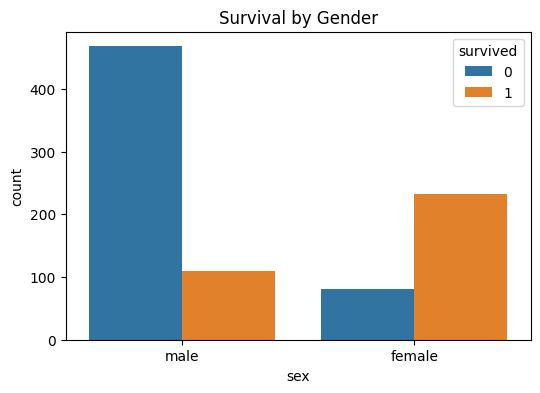

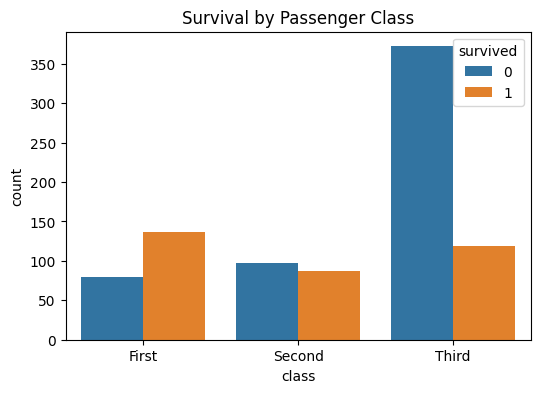

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Survival by Gender")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='class', hue='survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

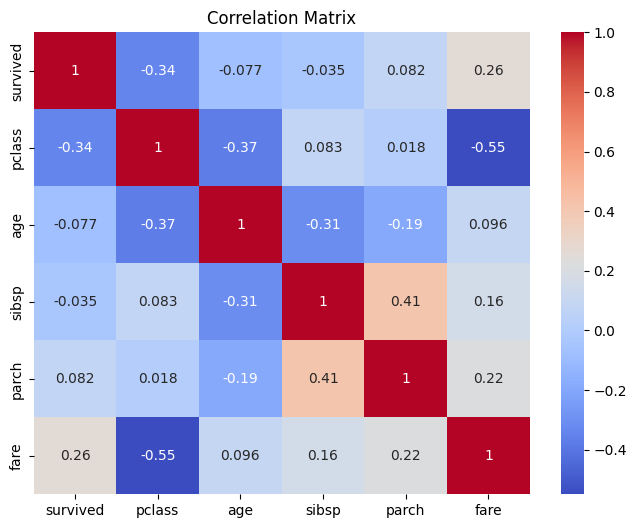

In [6]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()


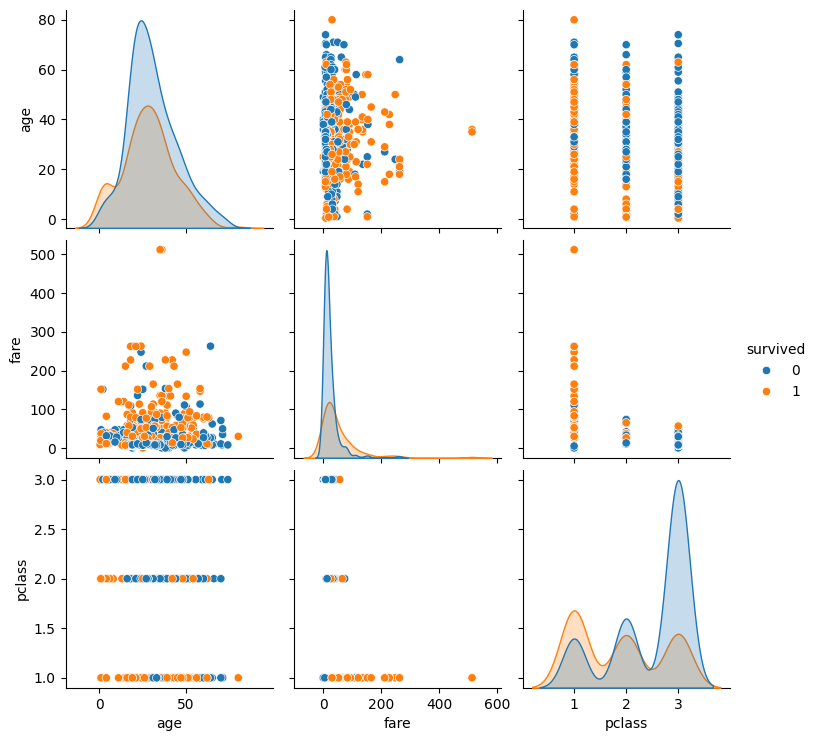

In [7]:
pair_df = df[['survived', 'age', 'fare', 'pclass']].dropna()

sns.pairplot(pair_df, hue='survived')

plt.show()

In [8]:
print("Survival Percentage")
print(df['survived'].value_counts(normalize=True) * 100)

print("\nAverage Age by Passenger Class")
print(df.groupby('class')['age'].mean())

print("\nAverage Fare by Passenger Class")
print(df.groupby('class')['fare'].mean())

Survival Percentage
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

Average Age by Passenger Class
class
First     38.233441
Second    29.877630
Third     25.140620
Name: age, dtype: float64

Average Fare by Passenger Class
class
First     84.154687
Second    20.662183
Third     13.675550
Name: fare, dtype: float64


/tmp/ipykernel_839/67281805.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('class')['age'].mean())
/tmp/ipykernel_839/67281805.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('class')['fare'].mean())
